In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
import cmcrameri
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
import statsmodels.api as sm
import pymannkendall as mk

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

In [3]:
def xr_add_cyclic_point(da):
    """
    Inputs
    da: xr.DataArray with dimensions (time,lat,lon)
    """
    from cartopy.util import add_cyclic_point
    import xarray as xr 

    # Use add_cyclic_point to interpolate input data
    lon_idx = da.dims.index('lon')
    wrap_data, wrap_lon = add_cyclic_point(da.values, coord=da.lon, axis=lon_idx)

    # Generate output DataArray with new data but same structure as input
    outp_da = xr.DataArray(data=wrap_data, 
                           coords = {'lat': da.lat, 'lon': wrap_lon}, 
                           dims=da.dims, 
                           attrs=da.attrs)
    
    return outp_da

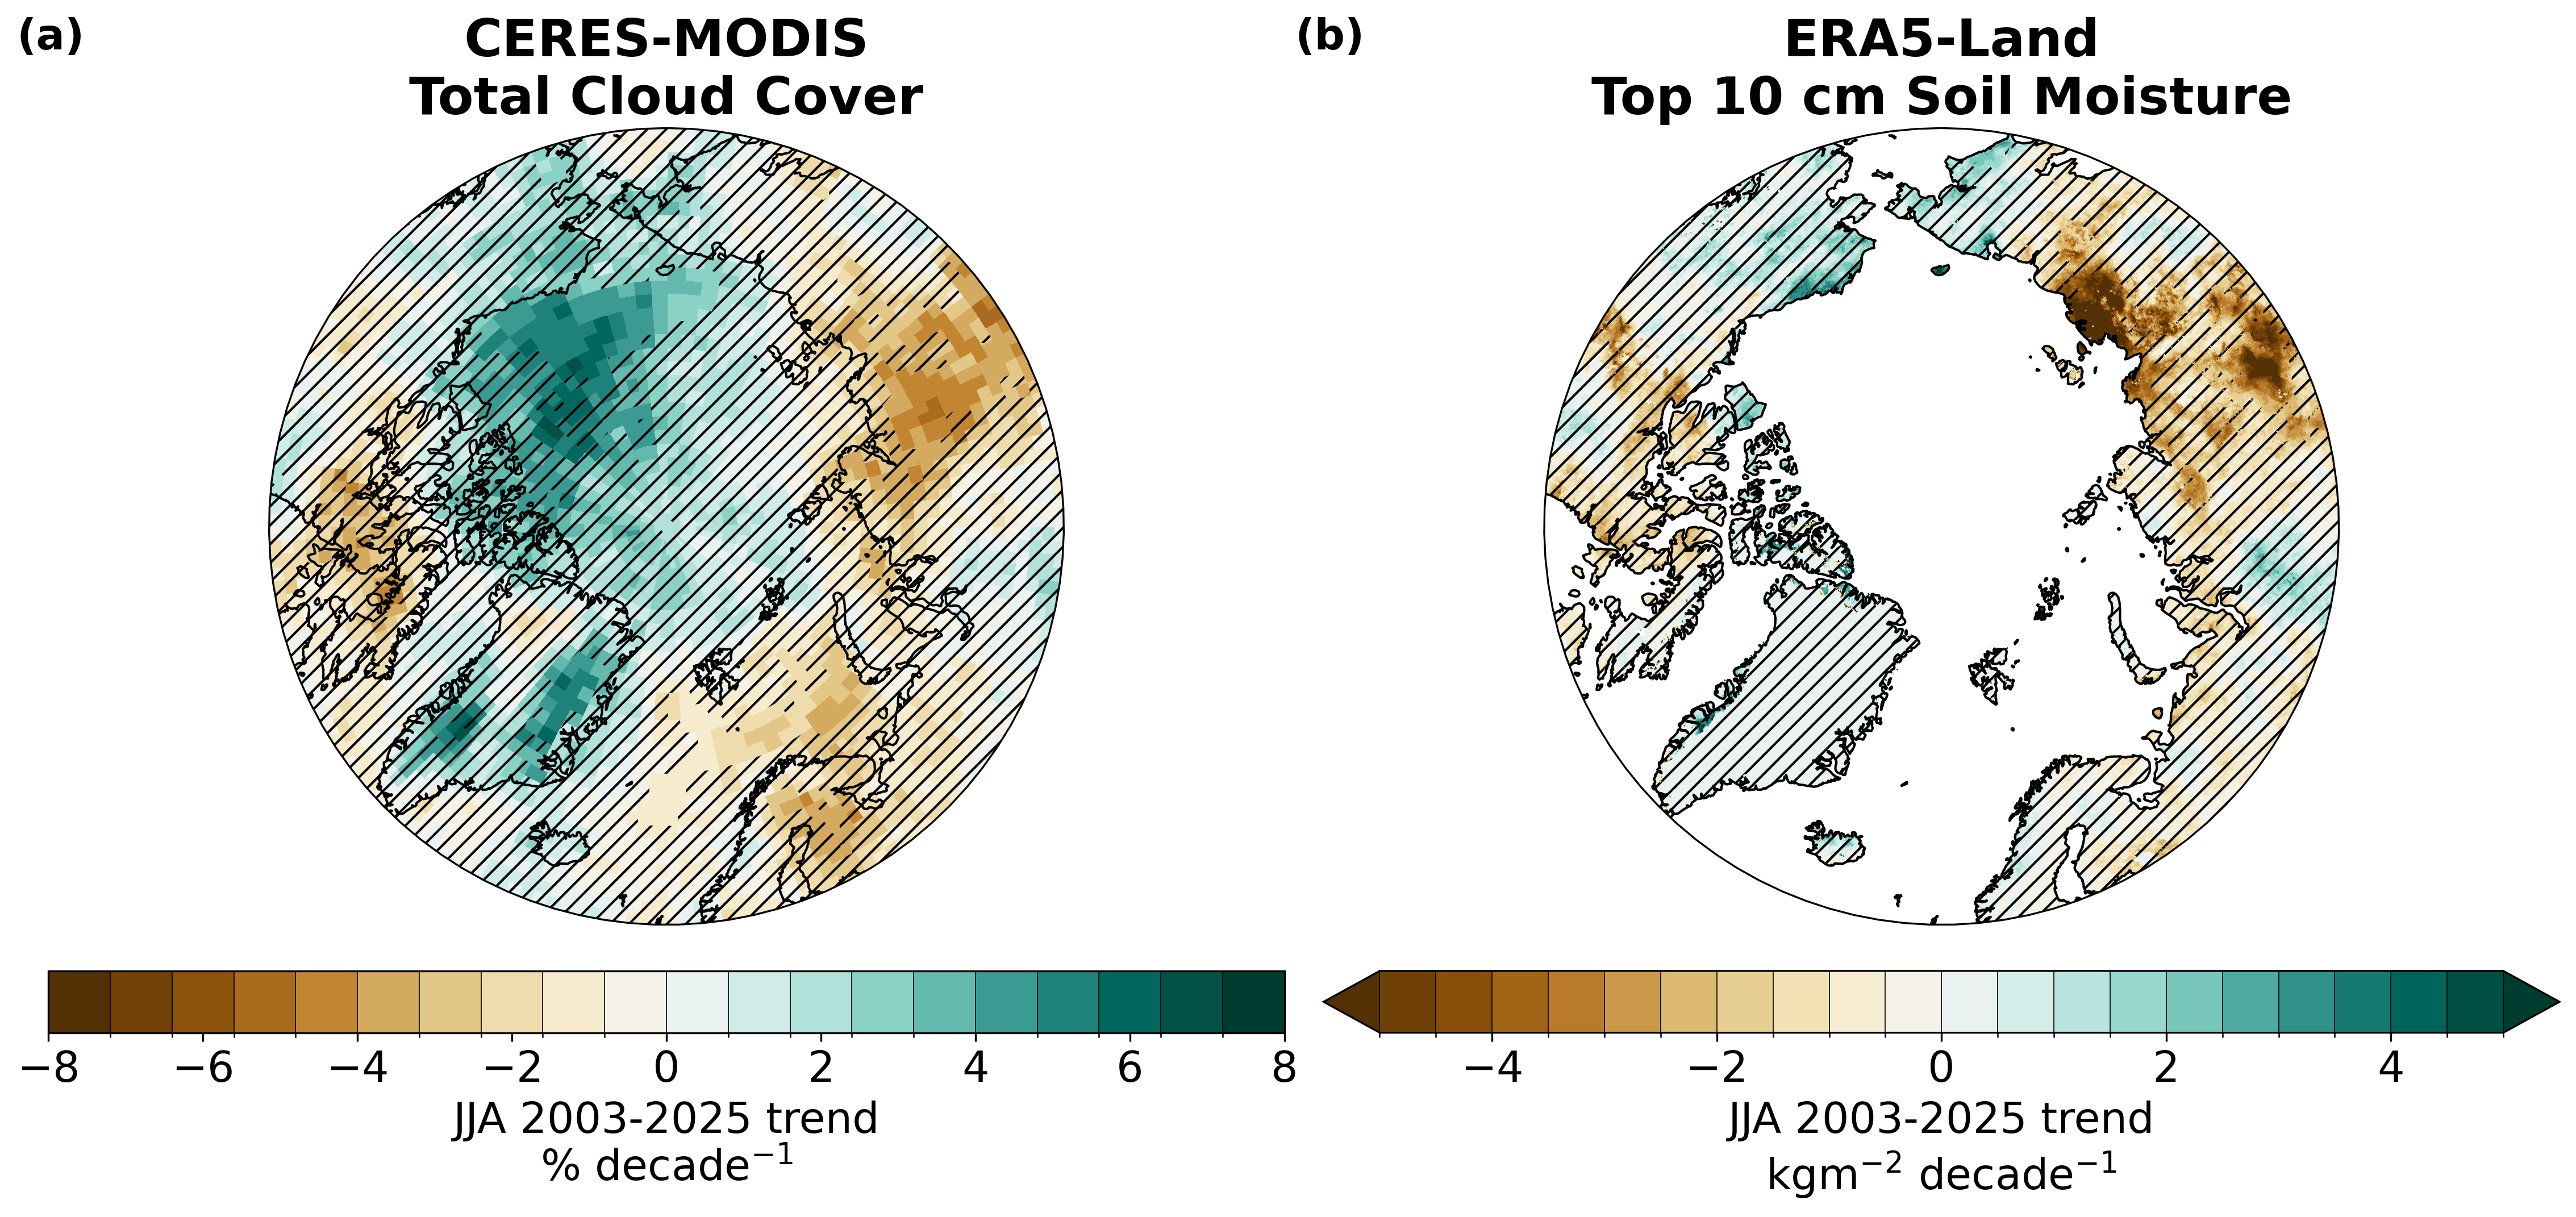

In [ ]:
labels = [['(a)','(a)','(b)','(b)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 7),dpi=300, 
                              constrained_layout=True)

# Remove axis from map plots
for label in ['(a)', '(b)']:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 90))


# Row |: spatial trends
for ax, title, unit, file, limit in zip([ax1, ax2], 
                                  ['CERES-MODIS\nTotal Cloud Cover', 'ERA5-Land\nTop 10 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['CERES_trends_JJA_2003_2025.nc', 'SM_ERA5_trends_JJA_2003_2025.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend'].T*10 # multiply by 10 to get trend per decade
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch_density=3
    hatch_style='/'
    insignificant_data = xr_add_cyclic_point(ds['p_value'].T > significance_level)
    hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    


    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    #hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2003-2025 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
#fig.tight_layout()

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA2.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA2.pdf')

In [16]:
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc')
CERES = CERES.sel(time=slice('2003-01-01','2025-12-1'))

CERES= CERES['cldarea_total_daynight_mon'].sel(time=CERES.time.dt.season=='JJA', lat=slice(55,90))
ds_annual = CERES.groupby(CERES.time.dt.year).mean('time')

trends = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
p_values = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
for ilon in range(len(CERES.lon)):
    for ilat in range(len(CERES.lat)):
        y = ds_annual.isel(lon=ilon, lat=ilat).values
        test = mk.original_test(y)

        trends[ilon, ilat] = test.slope
        p_values[ilon, ilat] = test.p

ds_annual['trend'] = ({'lon':CERES.lon, 'lat':CERES.lat}, trends)
ds_annual['p_value'] = ({'lon':CERES.lon, 'lat':CERES.lat}, p_values)

ds_annual.to_netcdf(rpath+"CERES_trends_JJA_2003_2025.nc")

In [25]:
# Select season
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')
timeslice_trend=slice('2003-01-01','2025-12-01')
SM_ERA5_slice = SM_ERA5.sel(time=timeslice_trend)
# Annual season mean
ds_season = SM_ERA5_slice['swvl_10cm'].sel(time=SM_ERA5_slice.time.dt.season=='JJA')
ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

trends = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
p_values = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
for ilon in range(len(SM_ERA5_slice.lon)):
    for ilat in range(len(SM_ERA5_slice.lat)):
        if np.isnan(ds_annual.isel(lon=ilon, lat=ilat).values).any():
            pass
       
        else:
            y = ds_annual.isel(lon=ilon, lat=ilat).values*100
            test = mk.original_test(y)

            trends[ilon, ilat] = test.slope
            p_values[ilon, ilat] = test.p

ds_annual['trend'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, trends)
ds_annual['p_value'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, p_values)

ds_annual.to_netcdf(rpath+"SM_ERA5_trends_JJA_2003_2025.nc")